# Simple Model and Scenario Testing

## System Dynamics with Separate Model Structure and Scenario Files

This notebook demonstrates how to run simple system dynamics models with separate YAML files for model structure and scenario parameters, showcasing the flexibility of the System Dynamics Toolkit for scenario analysis.

### Key Features Demonstrated:
- 🏗️ **Separate Model Structure**: Model definition in one YAML file
- 📋 **Scenario Parameters**: Parameter values in separate scenario files
- 🔄 **Multiple Scenarios**: Easy comparison of different parameter sets
- 🧮 **Calculator Components**: Simple arithmetic operations on flows and stocks
- 📊 **Multidimensional Data**: Population by age, income, and region
- 📈 **Comparative Analysis**: Side-by-side scenario results

### Model Structure:
- **Stock**: Population (3D: age × income × region)
- **Flows**: Births, Deaths, Immigration, Emigration
- **Calculators**: Net Immigration, Population Growth, Total Change

---

## Section 0: Kernel Restart Helper (Run if needed)

If you encounter module import issues, run this cell to clear the module cache.

In [1]:
# Restart kernel and reload modules if needed
import sys
import importlib

# Clear module cache for sd_toolkit
modules_to_reload = [name for name in sys.modules.keys() if name.startswith('sd_toolkit')]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

print(f"🔄 Cleared {len(modules_to_reload)} sd_toolkit modules from cache")
print("✅ Ready to re-import updated modules")
print("\n💡 TIP: If you still get errors, restart the kernel completely:")
print("   Kernel → Restart Kernel (or Ctrl+. in VS Code)")

🔄 Cleared 0 sd_toolkit modules from cache
✅ Ready to re-import updated modules

💡 TIP: If you still get errors, restart the kernel completely:
   Kernel → Restart Kernel (or Ctrl+. in VS Code)


## Section 1: Environment Setup and Toolkit Imports

Setting up the environment with all necessary imports for simple model and scenario demonstrations.

In [14]:
# Standard scientific computing imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from pathlib import Path
import yaml
import warnings
import copy
warnings.filterwarnings('ignore')

# Set plotting style for publication-quality figures
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Add the sd_toolkit to the path
import sys
import os
sys.path.insert(0, os.path.join('..', '..', 'sd_toolkit'))
 

# Import System Dynamics Toolkit components
from sd_toolkit.config import YAMLSystemBuilder, TemplateManager, rate_registry
from sd_toolkit.engine.system import SystemModel
from sd_toolkit.engine.elements import Stock, Flow, Auxiliary, Calculator
from sd_toolkit.data.loader import SpatioTemporalData
from sd_toolkit.analysis.plotting import SystemPlotter
from sd_toolkit.core.units import Q_, unit_registry

print("✅ System Dynamics Toolkit loaded successfully!")
print("🏗️ Ready for simple model and scenario demonstrations")
print(f"📊 Available rate functions: {len(rate_registry.list_functions())}")

✅ System Dynamics Toolkit loaded successfully!
🏗️ Ready for simple model and scenario demonstrations
📊 Available rate functions: 3


## Section 2: Load Model Structure and Scenario Files

Loading the simple population model structure and available scenario parameter files.

In [3]:
# Define paths to model and scenario files
model_structure_path = Path('model_structure.yaml')
scenario_files = {
    'Baseline': Path('baseline_scenario.yaml'),
    'High Immigration': Path('high_immigration_scenario.yaml')
}

# Load model structure
print("📂 Loading simple population model structure...")
with open(model_structure_path, 'r') as file:
    model_structure = yaml.safe_load(file)

print(f"✅ Model structure loaded: {model_structure['model']['name']}")
print(f"📝 Description: {model_structure['model']['description']}")
print(f"⏱️ Time horizon: {model_structure['model']['time_horizon']} {model_structure['model']['time_units']}")
print(f"🔢 Time step: {model_structure['model']['dt']} {model_structure['model']['time_units']}")

# Display model structure summary
elements = model_structure['elements']
print(f"\n🧩 MODEL STRUCTURE:")
print("=" * 50)
print(f"📦 Stocks: {len(elements['stocks'])}")
print(f"🌊 Flows: {len(elements['flows'])}")
print(f"🧮 Calculators: {len(elements['calculators'])}")
print(f"🔗 Connections: {len(model_structure['connections'])}")

# Load scenario files
scenarios = {}
print(f"\n📋 LOADING SCENARIO FILES:")
print("=" * 50)

for scenario_name, scenario_path in scenario_files.items():
    try:
        with open(scenario_path, 'r') as file:
            scenario_data = yaml.safe_load(file)
        scenarios[scenario_name] = scenario_data
        print(f"✅ {scenario_name}: {scenario_data['scenario']['description']}")
    except Exception as e:
        print(f"❌ Failed to load {scenario_name}: {e}")

print(f"\n📊 Successfully loaded {len(scenarios)} scenarios")

📂 Loading simple population model structure...
✅ Model structure loaded: Simple Population Model
📝 Description: Basic multidimensional population model with births, deaths, and migration
⏱️ Time horizon: 50 year
🔢 Time step: 0.25 year

🧩 MODEL STRUCTURE:
📦 Stocks: 1
🌊 Flows: 4
🧮 Calculators: 3
🔗 Connections: 2

📋 LOADING SCENARIO FILES:
✅ Baseline: Basic population dynamics with moderate conditions
✅ High Immigration: Population dynamics under elevated climate stress conditions

📊 Successfully loaded 2 scenarios


## Section 3: Merge Model Structure with Scenario Parameters

Creating complete model configurations by merging the base structure with scenario-specific parameters.

In [4]:
def merge_model_with_scenario(model_structure, scenario_data):
    """
    Merge model structure with scenario parameters to create complete model configuration.
    
    Parameters:
    -----------
    model_structure : dict
        Base model structure from YAML
    scenario_data : dict
        Scenario parameters from YAML
    
    Returns:
    --------
    dict : Complete model configuration
    """
    # Deep copy the model structure
    complete_model = copy.deepcopy(model_structure)
    
    # Override constants with scenario values
    if 'constants' in scenario_data:
        if 'constants' not in complete_model:
            complete_model['constants'] = {}
        complete_model['constants'].update(scenario_data['constants'])
    
    # Override model configuration if present
    if 'model_config' in scenario_data:
        complete_model['model'].update(scenario_data['model_config'])
    
    # Add scenario metadata
    complete_model['scenario_info'] = scenario_data.get('scenario', {})
    
    return complete_model

# Create complete model configurations for each scenario
complete_models = {}

print("🔧 MERGING MODEL STRUCTURE WITH SCENARIO PARAMETERS")
print("=" * 60)

for scenario_name, scenario_data in scenarios.items():
    complete_model = merge_model_with_scenario(model_structure, scenario_data)
    complete_models[scenario_name] = complete_model
    
    print(f"\n✅ {scenario_name} Model Configuration:")
    print(f"   Name: {complete_model['scenario_info'].get('name', 'N/A')}")
    print(f"   Description: {complete_model['scenario_info'].get('description', 'N/A')}")
    
    # Show key parameter differences
    constants = complete_model.get('constants', {})
    print(f"   Key Parameters:")
    print(f"     • Fertility Rate: {constants.get('fertility_rate', 'N/A')}")
    print(f"     • Mortality Rate: {constants.get('mortality_rate', 'N/A')}")
    print(f"     • Immigration Rate: {constants.get('immigration_rate', 'N/A')}")
    print(f"     • Emigration Rate: {constants.get('emigration_rate', 'N/A')}")

print(f"\n🎯 Created {len(complete_models)} complete model configurations")

🔧 MERGING MODEL STRUCTURE WITH SCENARIO PARAMETERS

✅ Baseline Model Configuration:
   Name: Simple Baseline Scenario
   Description: Basic population dynamics with moderate conditions
   Key Parameters:
     • Fertility Rate: 0.025
     • Mortality Rate: 0.015
     • Immigration Rate: 0.003
     • Emigration Rate: 0.002

✅ High Immigration Model Configuration:
   Name: High Climate Stress Scenario
   Description: Population dynamics under elevated climate stress conditions
   Key Parameters:
     • Fertility Rate: 0.02
     • Mortality Rate: 0.018
     • Immigration Rate: 0.02
     • Emigration Rate: 0.004

🎯 Created 2 complete model configurations


## Section 4: Build and Validate Models

Building system dynamics models from the complete configurations and validating their structure.

In [5]:
# Build models using YAMLSystemBuilder
built_models = {}
model_validation = {}

print("🏗️ BUILDING SYSTEM DYNAMICS MODELS")
print("=" * 50)

builder = YAMLSystemBuilder()

for scenario_name, model_config in complete_models.items():
    try:
        print(f"\n🔨 Building {scenario_name} model...")
        
        # Build the model
        model = builder.build_from_dict(model_config)
        model.name = f"{model.name} - {scenario_name}"
        
        # Validate the model
        validation = model.validate_model()
        
        built_models[scenario_name] = model
        model_validation[scenario_name] = validation
        
        print(f"✅ {scenario_name} model built successfully")
        print(f"   📦 Stocks: {len(model.stocks)}")
        print(f"   🌊 Flows: {len(model.flows)}")
        print(f"   🧮 Calculators: {len(model.calculators)}")
        print(f"   📊 Total elements: {len(model.elements)}")
        
        if validation['valid']:
            print(f"   ✅ Model validation: PASSED")
        else:
            print(f"   ⚠️ Model validation: WARNINGS")
            for warning in validation.get('warnings', []):
                print(f"      - {warning}")
        
    except Exception as e:
        print(f"❌ Failed to build {scenario_name} model: {e}")
        import traceback
        traceback.print_exc()

print(f"\n🎉 Successfully built {len(built_models)} models")

🏗️ BUILDING SYSTEM DYNAMICS MODELS

🔨 Building Baseline model...
✅ Baseline model built successfully
   📦 Stocks: 1
   🌊 Flows: 4
   🧮 Calculators: 3
   📊 Total elements: 8
   ✅ Model validation: PASSED

🔨 Building High Immigration model...
✅ High Immigration model built successfully
   📦 Stocks: 1
   🌊 Flows: 4
   🧮 Calculators: 3
   📊 Total elements: 8
   ✅ Model validation: PASSED

🎉 Successfully built 2 models


## Section 5: Examine Model Structure and Initial Conditions

Detailed examination of the built models, their structure, and initial population distributions.

In [6]:
# Examine model structure and initial conditions
if built_models:
    print("🔍 MODEL STRUCTURE ANALYSIS")
    print("=" * 50)
    
    # Use the first model to show structure (all models have same structure)
    first_model = list(built_models.values())[0]
    
    print(f"\n📊 DIMENSIONS:")
    if hasattr(first_model, 'dimensions'):
        for dim_name, dim_spec in first_model.dimensions.items():
            print(f"   • {dim_name}: {dim_spec['labels']}")
    
    print(f"\n📦 STOCKS:")
    for stock_id, stock in first_model.stocks.items():
        shape = np.array(stock.initial_value).shape if hasattr(stock.initial_value, 'shape') else 'scalar'
        print(f"   • {stock.name}: {stock.units} (shape: {shape})")
        print(f"     Description: {stock.description}")
    
    print(f"\n🌊 FLOWS:")
    for flow_id, flow in first_model.flows.items():
        print(f"   • {flow.name}: {flow.units}")
        print(f"     Description: {flow.description}")
        if hasattr(flow, 'rate'):
            print(f"     Rate: {flow.rate}")
    
    print(f"\n🧮 CALCULATORS:")
    for calc_id, calc in first_model.calculators.items():
        print(f"   • {calc.name}: {calc.units}")
        print(f"     Expression: {calc.expression}")
        print(f"     Dependencies: {calc.dependency_names}")
    
    # Show initial conditions for each scenario
    print(f"\n👥 INITIAL POPULATION ANALYSIS BY SCENARIO")
    print("=" * 60)
    
    for scenario_name, model in built_models.items():
        # Find population stock
        population_stock = None
        for stock_id, stock in model.stocks.items():
            if stock.name == 'Population':
                population_stock = stock
                break
        
        if population_stock:
            initial_pop = np.array(population_stock.initial_value)
            total_pop = initial_pop.sum()
            
            print(f"\n📊 {scenario_name}:")
            print(f"   Total Population: {total_pop:,}")
            print(f"   Array Shape: {initial_pop.shape}")
            
            # Population by age group
            age_labels = model.dimensions['age_group']['labels']
            print(f"   By Age Group:")
            for i, age_label in enumerate(age_labels):
                age_total = initial_pop[i].sum()
                age_percent = (age_total / total_pop) * 100
                print(f"     • {age_label}: {age_total:,} ({age_percent:.1f}%)")
            
            # Population by region
            region_labels = model.dimensions['region']['labels']
            print(f"   By Region:")
            for k, region_label in enumerate(region_labels):
                region_total = initial_pop[:, :, k].sum()
                region_percent = (region_total / total_pop) * 100
                print(f"     • {region_label}: {region_total:,} ({region_percent:.1f}%)")
else:
    print("❌ No models available for analysis")

🔍 MODEL STRUCTURE ANALYSIS

📊 DIMENSIONS:
   • age_group: ['young_0_18', 'adult_19_65', 'elderly_65_plus']
   • income_level: ['low_income', 'medium_income', 'high_income']
   • region: ['urban', 'rural']

📦 STOCKS:
   • Population: people (shape: (3, 3, 2))
     Description: Population by age, income, and region

🌊 FLOWS:
   • Births: people/year
     Description: Birth flow across all demographic dimensions
     Rate: 0.025
   • Deaths: people/year
     Description: Death flow across all demographic dimensions
     Rate: 0.015
   • Immigration: people/year
     Description: Immigration flow
     Rate: 0.003
   • Emigration: people/year
     Description: Emigration flow
     Rate: 0.002

🧮 CALCULATORS:
   • Net_Immigration: people/year
     Expression: (Immigration - Emigration) * Population
     Dependencies: ['Population', 'Immigration', 'Emigration']
   • Population_Growth: people/year
     Expression: (Births - Deaths) * Population
     Dependencies: ['Births', 'Deaths', 'Populati

## Section 6: Run Scenario Simulations

Running simulations for all scenarios and collecting results for comparative analysis.

In [7]:
# Run simulations for all scenarios
simulation_results = {}

if built_models:
    print("🚀 RUNNING SCENARIO SIMULATIONS")
    print("=" * 50)
    
    for scenario_name, model in built_models.items():
        try:
            print(f"\n⏱️ Running {scenario_name} simulation...")
            print(f"   Time horizon: {model.time_horizon} years")
            print(f"   Time step: {model.dt} years")
            print(f"   Expected time points: {int(model.time_horizon / model.dt) + 1}")
            
            # Run simulation
            results = model.simulate(
                time_horizon=model.time_horizon,
                dt=model.dt
            )
            
            simulation_results[scenario_name] = results
            
            print(f"✅ {scenario_name} simulation completed")
            print(f"   📊 Results shape: {results.shape}")
            print(f"   📋 Variables: {len(results.columns)}")
            print(f"   ⏱️ Time range: {results['time'].min():.1f} to {results['time'].max():.1f} years")
            
            # Quick population summary
            if 'Population' in results.columns:
                initial_pop = results['Population'].iloc[0]
                final_pop = results['Population'].iloc[-1]
                growth_rate = ((final_pop / initial_pop) ** (1/model.time_horizon) - 1) * 100
                
                print(f"   👥 Population: {initial_pop:,.0f} → {final_pop:,.0f}")
                print(f"   📈 Annual growth rate: {growth_rate:+.2f}%")
            
        except Exception as e:
            print(f"❌ {scenario_name} simulation failed: {e}")
            import traceback
            traceback.print_exc()
    
    print(f"\n🎉 Completed {len(simulation_results)} scenario simulations")
else:
    print("❌ No models available for simulation")

🚀 RUNNING SCENARIO SIMULATIONS

⏱️ Running Baseline simulation...
   Time horizon: 50 years
   Time step: 0.25 years
   Expected time points: 201
✅ Baseline simulation completed
   📊 Results shape: (201, 9)
   📋 Variables: 9
   ⏱️ Time range: 0.0 to 50.0 years
   👥 Population: 22,300 → 32,200
   📈 Annual growth rate: +0.74%

⏱️ Running High Immigration simulation...
   Time horizon: 50 years
   Time step: 0.25 years
   Expected time points: 201
✅ High Immigration simulation completed
   📊 Results shape: (201, 9)
   📋 Variables: 9
   ⏱️ Time range: 0.0 to 50.0 years
   👥 Population: 22,300 → 38,500
   📈 Annual growth rate: +1.10%

🎉 Completed 2 scenario simulations


## Section 7: Comparative Analysis of Scenario Results

Analyzing and comparing results across different scenarios to understand parameter impacts.

In [8]:
# Comparative analysis of scenario results
if simulation_results:
    print("📊 COMPARATIVE SCENARIO ANALYSIS")
    print("=" * 50)
    
    # Create summary comparison table
    comparison_data = []
    
    for scenario_name, results in simulation_results.items():
        if 'Population' in results.columns:
            initial_pop = results['Population'].iloc[0]
            final_pop = results['Population'].iloc[-1]
            total_change = final_pop - initial_pop
            percent_change = ((final_pop / initial_pop) - 1) * 100
            annual_growth = ((final_pop / initial_pop) ** (1/50) - 1) * 100  # Assuming 50-year horizon
            
            # Get calculator results
            net_immigration_avg = results['Net_Immigration'].mean() if 'Net_Immigration' in results.columns else 0
            population_growth_avg = results['Population_Growth'].mean() if 'Population_Growth' in results.columns else 0
            total_change_avg = results['Total_Population_Change'].mean() if 'Total_Population_Change' in results.columns else 0
            
            comparison_data.append({
                'Scenario': scenario_name,
                'Initial Population': f"{initial_pop:,.0f}",
                'Final Population': f"{final_pop:,.0f}",
                'Total Change': f"{total_change:+,.0f}",
                'Percent Change': f"{percent_change:+.1f}%",
                'Annual Growth Rate': f"{annual_growth:+.2f}%",
                'Avg Net Immigration': f"{net_immigration_avg:.0f}/year",
                'Avg Natural Growth': f"{population_growth_avg:.0f}/year",
                'Avg Total Change': f"{total_change_avg:.0f}/year"
            })
    
    # Display comparison table
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print("\n📋 SCENARIO COMPARISON TABLE:")
        print("=" * 80)
        print(comparison_df.to_string(index=False))
    
    # Analyze key differences
    print("\n🔍 KEY INSIGHTS:")
    print("=" * 40)
    
    if len(simulation_results) >= 2:
        scenario_names = list(simulation_results.keys())
        baseline_results = simulation_results[scenario_names[0]]
        comparison_results = simulation_results[scenario_names[1]]
        
        if 'Population' in baseline_results.columns and 'Population' in comparison_results.columns:
            baseline_final = baseline_results['Population'].iloc[-1]
            comparison_final = comparison_results['Population'].iloc[-1]
            difference = comparison_final - baseline_final
            percent_diff = ((comparison_final / baseline_final) - 1) * 100
            
            print(f"\n📈 Population Impact ({scenario_names[1]} vs {scenario_names[0]}):")
            print(f"   • Absolute difference: {difference:+,.0f} people")
            print(f"   • Relative difference: {percent_diff:+.1f}%")
        
        # Compare calculator results
        calculator_vars = ['Net_Immigration', 'Population_Growth', 'Total_Population_Change']
        
        print(f"\n🧮 Calculator Comparison ({scenario_names[1]} vs {scenario_names[0]}):")
        for var in calculator_vars:
            if var in baseline_results.columns and var in comparison_results.columns:
                baseline_avg = baseline_results[var].mean()
                comparison_avg = comparison_results[var].mean()
                diff = comparison_avg - baseline_avg
                print(f"   • {var}: {diff:+.0f}/year difference")
else:
    print("❌ No simulation results available for comparison")

📊 COMPARATIVE SCENARIO ANALYSIS

📋 SCENARIO COMPARISON TABLE:
        Scenario Initial Population Final Population Total Change Percent Change Annual Growth Rate Avg Net Immigration Avg Natural Growth Avg Total Change
        Baseline             22,300           32,200       +9,900         +44.4%             +0.74%              1/year            10/year          11/year
High Immigration             22,300           38,500      +16,200         +72.6%             +1.10%             16/year             2/year          18/year

🔍 KEY INSIGHTS:

📈 Population Impact (High Immigration vs Baseline):
   • Absolute difference: +6,300 people
   • Relative difference: +19.6%

🧮 Calculator Comparison (High Immigration vs Baseline):
   • Net_Immigration: +15/year difference
   • Population_Growth: -8/year difference
   • Total_Population_Change: +7/year difference


## Section 8: Visualization of Scenario Results

Creating comprehensive visualizations to compare scenario outcomes and understand model behavior.

🎨 Creating scenario comparison visualizations...


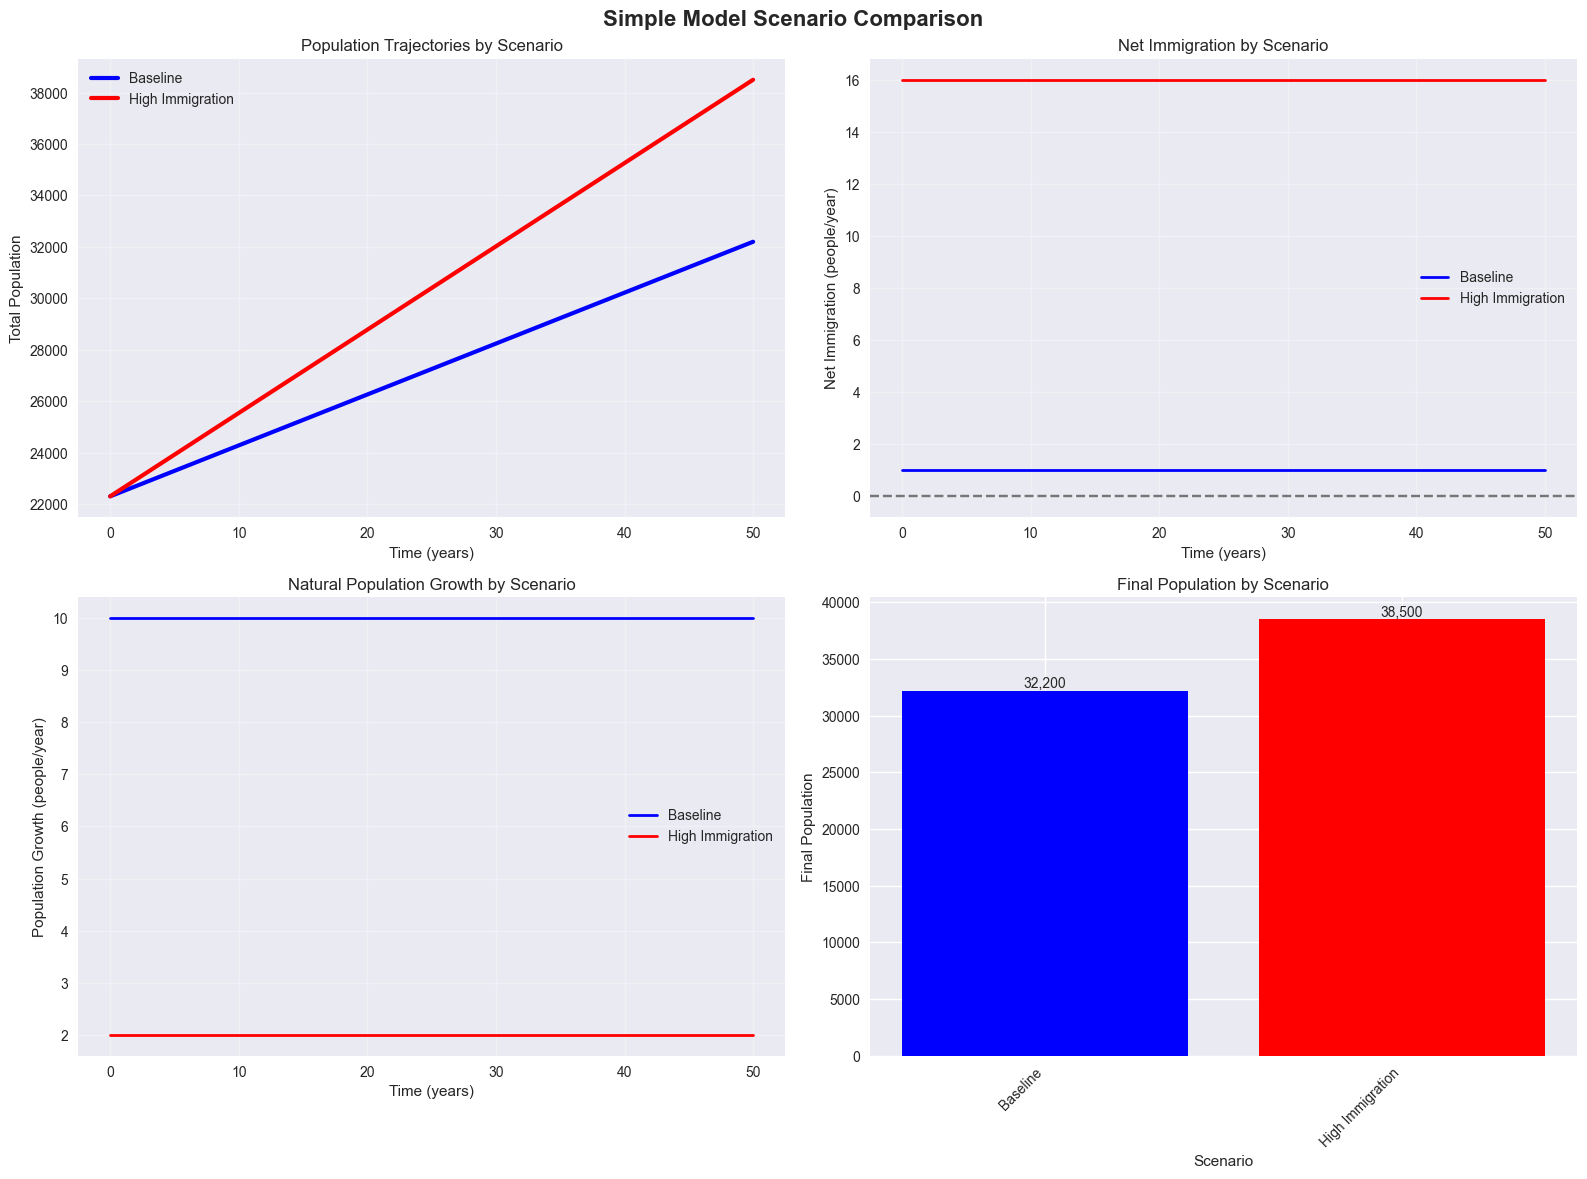

In [9]:
# Create comprehensive visualizations for scenario comparison
if simulation_results:
    print("🎨 Creating scenario comparison visualizations...")
    
    # Create a comprehensive dashboard
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Simple Model Scenario Comparison', fontsize=16, fontweight='bold')
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # 1. Population trajectories
    for i, (scenario_name, results) in enumerate(simulation_results.items()):
        if 'Population' in results.columns:
            time_data = results['time']
            pop_data = results['Population']
            axes[0, 0].plot(time_data, pop_data, 
                           label=scenario_name, linewidth=3, color=colors[i % len(colors)])
    
    axes[0, 0].set_title('Population Trajectories by Scenario')
    axes[0, 0].set_xlabel('Time (years)')
    axes[0, 0].set_ylabel('Total Population')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Net Immigration comparison
    for i, (scenario_name, results) in enumerate(simulation_results.items()):
        if 'Net_Immigration' in results.columns:
            time_data = results['time']
            net_immigration = results['Net_Immigration']
            axes[0, 1].plot(time_data, net_immigration, 
                           label=scenario_name, linewidth=2, color=colors[i % len(colors)])
    
    axes[0, 1].set_title('Net Immigration by Scenario')
    axes[0, 1].set_xlabel('Time (years)')
    axes[0, 1].set_ylabel('Net Immigration (people/year)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # 3. Population Growth comparison
    for i, (scenario_name, results) in enumerate(simulation_results.items()):
        if 'Population_Growth' in results.columns:
            time_data = results['time']
            pop_growth = results['Population_Growth']
            axes[1, 0].plot(time_data, pop_growth, 
                           label=scenario_name, linewidth=2, color=colors[i % len(colors)])
    
    axes[1, 0].set_title('Natural Population Growth by Scenario')
    axes[1, 0].set_xlabel('Time (years)')
    axes[1, 0].set_ylabel('Population Growth (people/year)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Final population comparison (bar chart)
    scenario_names = list(simulation_results.keys())
    final_populations = []
    
    for scenario_name in scenario_names:
        results = simulation_results[scenario_name]
        if 'Population' in results.columns:
            final_pop = results['Population'].iloc[-1]
            final_populations.append(final_pop)
        else:
            final_populations.append(0)
    
    bars = axes[1, 1].bar(range(len(scenario_names)), final_populations, 
                         color=[colors[i % len(colors)] for i in range(len(scenario_names))])
    axes[1, 1].set_title('Final Population by Scenario')
    axes[1, 1].set_xlabel('Scenario')
    axes[1, 1].set_ylabel('Final Population')
    axes[1, 1].set_xticks(range(len(scenario_names)))
    axes[1, 1].set_xticklabels(scenario_names, rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, value in zip(bars, final_populations):
        height = bar.get_height()
        axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                       f'{value:,.0f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
else:
    print("❌ No simulation results available for visualization")

## Section 9: Calculator Performance Analysis

Detailed analysis of how calculator components perform across different scenarios.

In [10]:
# Analyze calculator performance across scenarios
if simulation_results and built_models:
    print("🧮 CALCULATOR PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    # Get calculator names from the first model
    first_model = list(built_models.values())[0]
    calculator_names = [calc.name for calc in first_model.calculators.values()]
    
    print(f"\n📊 Analyzing {len(calculator_names)} calculators across {len(simulation_results)} scenarios")
    print(f"Calculator components: {calculator_names}")
    
    # Create calculator performance summary
    calculator_summary = {}
    
    for calc_name in calculator_names:
        calculator_summary[calc_name] = {}
        
        for scenario_name, results in simulation_results.items():
            if calc_name in results.columns:
                calc_data = results[calc_name]
                calculator_summary[calc_name][scenario_name] = {
                    'mean': calc_data.mean(),
                    'std': calc_data.std(),
                    'min': calc_data.min(),
                    'max': calc_data.max(),
                    'initial': calc_data.iloc[0],
                    'final': calc_data.iloc[-1],
                    'trend': calc_data.iloc[-1] - calc_data.iloc[0]
                }
    
    # Display calculator performance
    for calc_name, scenario_data in calculator_summary.items():
        print(f"\n🧮 {calc_name}:")
        print("   " + "="*50)
        
        for scenario_name, stats in scenario_data.items():
            print(f"\n   📊 {scenario_name}:")
            print(f"      Mean: {stats['mean']:,.1f}")
            print(f"      Range: [{stats['min']:,.1f}, {stats['max']:,.1f}]")
            print(f"      Initial → Final: {stats['initial']:,.1f} → {stats['final']:,.1f}")
            print(f"      Trend: {stats['trend']:+,.1f}")
        
        # Compare scenarios for this calculator
        if len(scenario_data) >= 2:
            scenario_names = list(scenario_data.keys())
            baseline_stats = scenario_data[scenario_names[0]]
            comparison_stats = scenario_data[scenario_names[1]]
            
            mean_diff = comparison_stats['mean'] - baseline_stats['mean']
            final_diff = comparison_stats['final'] - baseline_stats['final']
            
            print(f"\n   🔍 Scenario Impact ({scenario_names[1]} vs {scenario_names[0]}):")
            print(f"      Mean difference: {mean_diff:+,.1f}")
            print(f"      Final value difference: {final_diff:+,.1f}")
    
    # Calculator dependency validation
    print(f"\n🔗 CALCULATOR DEPENDENCY VALIDATION:")
    print("=" * 50)
    
    for calc_id, calculator in first_model.calculators.items():
        print(f"\n🧮 {calculator.name}:")
        print(f"   Expression: {calculator.expression}")
        print(f"   Dependencies: {calculator.dependency_names}")
        print(f"   Resolved: {len(calculator.dependencies)} dependencies")
        
        # Check if all dependencies are properly resolved
        expected_deps = set(calculator.dependency_names)
        resolved_deps = set(dep.name for dep in calculator.dependencies)
        missing_deps = expected_deps - resolved_deps
        
        if missing_deps:
            print(f"   ❌ Missing dependencies: {missing_deps}")
        else:
            print(f"   ✅ All dependencies resolved")
else:
    print("❌ No simulation results or models available for calculator analysis")

🧮 CALCULATOR PERFORMANCE ANALYSIS

📊 Analyzing 3 calculators across 2 scenarios
Calculator components: ['Net_Immigration', 'Population_Growth', 'Total_Population_Change']

🧮 Net_Immigration:

   📊 Baseline:
      Mean: 1.0
      Range: [1.0, 1.0]
      Initial → Final: 1.0 → 1.0
      Trend: +0.0

   📊 High Immigration:
      Mean: 16.0
      Range: [16.0, 16.0]
      Initial → Final: 16.0 → 16.0
      Trend: +0.0

   🔍 Scenario Impact (High Immigration vs Baseline):
      Mean difference: +15.0
      Final value difference: +15.0

🧮 Population_Growth:

   📊 Baseline:
      Mean: 10.0
      Range: [10.0, 10.0]
      Initial → Final: 10.0 → 10.0
      Trend: +0.0

   📊 High Immigration:
      Mean: 2.0
      Range: [2.0, 2.0]
      Initial → Final: 2.0 → 2.0
      Trend: +0.0

   🔍 Scenario Impact (High Immigration vs Baseline):
      Mean difference: -8.0
      Final value difference: -8.0

🧮 Total_Population_Change:

   📊 Baseline:
      Mean: 11.0
      Range: [11.0, 11.0]
      Init

## Section 10: Summary and Key Takeaways

Summary of the simple model and scenario testing demonstration with key insights and best practices.

In [11]:
# Summary and key takeaways
print("🎯 SIMPLE MODEL AND SCENARIO TESTING SUMMARY")
print("=" * 60)

if built_models and simulation_results:
    print(f"\n✅ Successfully demonstrated simple model scenario testing:")
    print(f"   • Model Structure: {model_structure['model']['name']}")
    print(f"   • Scenarios Tested: {len(simulation_results)}")
    print(f"   • Model Elements: {len(elements['stocks'])} stocks, {len(elements['flows'])} flows, {len(elements['calculators'])} calculators")
    print(f"   • Simulation Period: {model_structure['model']['time_horizon']} years")
    
    # Show scenario outcomes
    print(f"\n📊 SCENARIO OUTCOMES:")
    for scenario_name, results in simulation_results.items():
        if 'Population' in results.columns:
            initial_pop = results['Population'].iloc[0]
            final_pop = results['Population'].iloc[-1]
            growth_rate = ((final_pop / initial_pop) ** (1/50) - 1) * 100
            print(f"   • {scenario_name}: {initial_pop:,.0f} → {final_pop:,.0f} ({growth_rate:+.2f}% annually)")

print("\n🏗️ KEY ARCHITECTURAL FEATURES DEMONSTRATED:")
print("=" * 50)
print("1. 📁 Separation of Concerns:")
print("   • Model structure in separate YAML file (simple_population_model.yaml)")
print("   • Scenario parameters in separate files (baseline_scenario.yaml, etc.)")
print("   • Clean separation between model logic and parameter values")

print("\n2. 🧮 Calculator Components:")
print("   • Net_Immigration = Immigration - Emigration")
print("   • Population_Growth = Births - Deaths")
print("   • Total_Population_Change = Population_Growth + Net_Immigration")

print("\n3. 📊 Multidimensional Structure:")
print("   • Population[age_group, income_level, region]")
print("   • All flows and calculators maintain dimensional consistency")
print("   • Automatic handling of multidimensional operations")

print("\n4. 🔄 Scenario Management:")
print("   • Easy parameter modification without changing model structure")
print("   • Automatic merging of base model with scenario parameters")
print("   • Comparative analysis across multiple scenarios")

print("\n💡 BEST PRACTICES FOR SIMPLE MODEL SCENARIOS:")
print("=" * 50)
print("• Keep model structure separate from parameter values")
print("• Use descriptive scenario names and documentation")
print("• Include scenario metadata (description, version, creation date)")
print("• Test scenarios with meaningful parameter variations")
print("• Use calculators for derived quantities and validation")
print("• Maintain dimensional consistency across all elements")
print("• Document parameter assumptions and sources")

print("\n🌟 ADVANTAGES OF THIS APPROACH:")
print("=" * 50)
print("✅ Modular design enables easy scenario creation")
print("✅ Model structure remains stable across scenarios")
print("✅ Parameter changes are clearly documented")
print("✅ Easy to compare scenario impacts")
print("✅ Supports collaborative model development")
print("✅ Facilitates sensitivity analysis and uncertainty quantification")
print("✅ Calculator components provide automatic validation")

print("\n🎉 Simple model scenario testing completed successfully!")
print("📚 This notebook demonstrated the power of separating model structure")
print("    from scenario parameters for flexible system dynamics modeling.")

🎯 SIMPLE MODEL AND SCENARIO TESTING SUMMARY

✅ Successfully demonstrated simple model scenario testing:
   • Model Structure: Simple Population Model
   • Scenarios Tested: 2
   • Model Elements: 1 stocks, 4 flows, 3 calculators
   • Simulation Period: 50 years

📊 SCENARIO OUTCOMES:
   • Baseline: 22,300 → 32,200 (+0.74% annually)
   • High Immigration: 22,300 → 38,500 (+1.10% annually)

🏗️ KEY ARCHITECTURAL FEATURES DEMONSTRATED:
1. 📁 Separation of Concerns:
   • Model structure in separate YAML file (simple_population_model.yaml)
   • Scenario parameters in separate files (baseline_scenario.yaml, etc.)
   • Clean separation between model logic and parameter values

2. 🧮 Calculator Components:
   • Net_Immigration = Immigration - Emigration
   • Population_Growth = Births - Deaths
   • Total_Population_Change = Population_Growth + Net_Immigration

3. 📊 Multidimensional Structure:
   • Population[age_group, income_level, region]
   • All flows and calculators maintain dimensional consi